# Regresión Lineal — Terrenos (Ridge + Lasso)

Modelo predictivo de precios de terrenos en Cantabria sobre `data/gold/final_land_scraping.csv`.

**Hipótesis de partida:** tras el target encoding de `municipio` y el OHE de `tipo_suelo`, el problema es esencialmente lineal. Ridge y Lasso son candidatos naturales. Lasso actuará además como selector automático de features — se espera que zerée `superficie_m2` y `vendido_con_descuento`, cuya correlación con el target es prácticamente nula (r=0.07 y r=-0.02 respectivamente).

**Target:** `log_precio` (log natural del precio en €). Las métricas finales se interpretan también en € mediante back-transformation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga y preparación

In [2]:
df = pd.read_csv('../../data/gold/final_land_scraping.csv')

# Sanitizar nombres de columnas (espacios y paréntesis pueden causar problemas)
df.columns = (
    df.columns
    .str.replace(' ', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

TARGET  = 'log_precio'
EXCLUDE = ['precio_eur', TARGET]
FEATURES = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Shape dataset: {df.shape}')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Shape dataset: (686, 9)
Train: (548, 7) | Test: (138, 7)
Features (7): ['superficie_m2', 'vendido_con_descuento', 'es_urbano_o_urbanizable', 'municipio_encoded', 'tipo_suelo_No_urbanizable', 'tipo_suelo_Urbanizable', 'tipo_suelo_Urbano_solar']


## 2. Correlación de features con el target

Correlación con log_precio:
es_urbano_o_urbanizable      0.521
tipo_suelo_Urbano_solar      0.352
municipio_encoded            0.349
tipo_suelo_Urbanizable       0.056
vendido_con_descuento       -0.007
superficie_m2               -0.045
tipo_suelo_No_urbanizable   -0.521


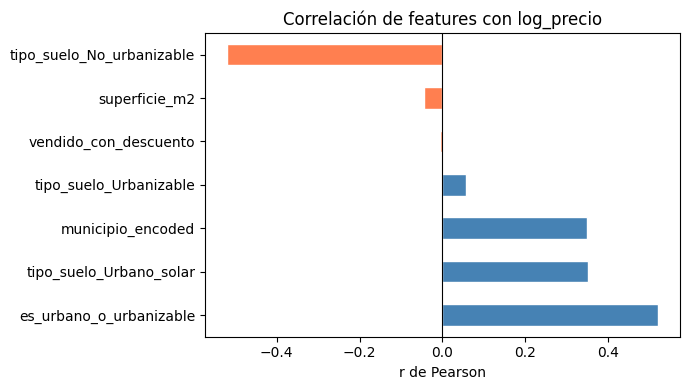

In [3]:
corr = X.join(y).corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(ascending=False)

print('Correlación con log_precio:')
print(corr.round(3).to_string())

colors = ['steelblue' if v > 0 else 'coral' for v in corr]
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de features con log_precio')
ax.set_xlabel('r de Pearson')
plt.tight_layout()
plt.show()

## 3. Función de métricas

In [4]:
def get_metrics(model, X_tr, X_te, y_tr, y_te, name=''):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    m = {
        'RMSE_train': np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_te, y_pred_te)),
        'R2_train':   r2_score(y_tr, y_pred_tr),
        'R2_test':    r2_score(y_te, y_pred_te),
        'MAE_test':   mean_absolute_error(y_te, y_pred_te),
    }
    if name:
        print(f'--- {name} ---')
        for k, v in m.items():
            print(f'  {k}: {v:.4f}')
    return m

## 4. Ridge Regression

Mejor alpha Ridge: 9.1627


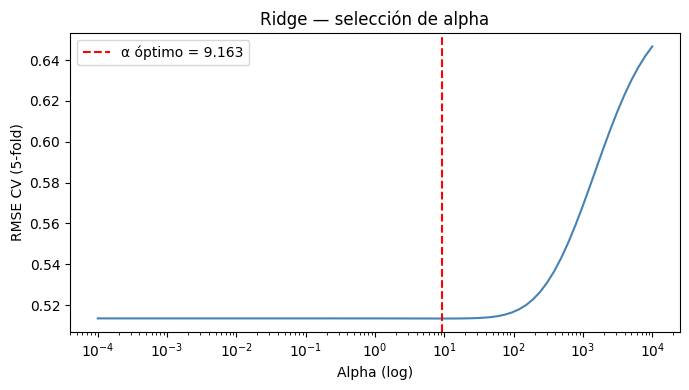

In [5]:
alphas = np.logspace(-4, 4, 80)

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])
ridge_gs = GridSearchCV(
    ridge_pipe,
    {'ridge__alpha': alphas},
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
ridge_gs.fit(X_train, y_train)

best_ridge      = ridge_gs.best_estimator_
best_alpha_ridge = ridge_gs.best_params_['ridge__alpha']
print(f'Mejor alpha Ridge: {best_alpha_ridge:.4f}')

# Curva de selección de alpha
cv_rmse = -ridge_gs.cv_results_['mean_test_score']
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, cv_rmse, color='steelblue', linewidth=1.5)
ax.axvline(best_alpha_ridge, color='red', linestyle='--', label=f'α óptimo = {best_alpha_ridge:.3f}')
ax.set_xlabel('Alpha (log)')
ax.set_ylabel('RMSE CV (5-fold)')
ax.set_title('Ridge — selección de alpha')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
metrics_ridge = get_metrics(best_ridge, X_train, X_test, y_train, y_test, name='Ridge')

--- Ridge ---
  RMSE_train: 0.5081
  RMSE_test: 0.5470
  R2_train: 0.4213
  R2_test: 0.3076
  MAE_test: 0.4260


## 5. Lasso Regression

In [7]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(max_iter=20000))
])
lasso_gs = GridSearchCV(
    lasso_pipe,
    {'lasso__alpha': alphas},
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lasso_gs.fit(X_train, y_train)

best_lasso      = lasso_gs.best_estimator_
best_alpha_lasso = lasso_gs.best_params_['lasso__alpha']
print(f'Mejor alpha Lasso: {best_alpha_lasso:.4f}')

# Features zeroed por Lasso
lasso_coefs = pd.Series(
    best_lasso.named_steps['lasso'].coef_,
    index=FEATURES
)
zeroed = lasso_coefs[lasso_coefs == 0].index.tolist()
active = lasso_coefs[lasso_coefs != 0].index.tolist()
print(f'\nFeatures activas ({len(active)}): {active}')
print(f'Features zeroed  ({len(zeroed)}): {zeroed}')

Mejor alpha Lasso: 0.0066

Features activas (5): ['superficie_m2', 'es_urbano_o_urbanizable', 'municipio_encoded', 'tipo_suelo_No_urbanizable', 'tipo_suelo_Urbano_solar']
Features zeroed  (2): ['vendido_con_descuento', 'tipo_suelo_Urbanizable']


In [8]:
metrics_lasso = get_metrics(best_lasso, X_train, X_test, y_train, y_test, name='Lasso')

--- Lasso ---
  RMSE_train: 0.5083
  RMSE_test: 0.5462
  R2_train: 0.4209
  R2_test: 0.3097
  MAE_test: 0.4259


## 6. Comparativa de métricas y coeficientes

In [9]:
summary = pd.DataFrame({
    'Ridge': metrics_ridge,
    'Lasso': metrics_lasso
}).T.round(4)

print('Comparativa Ridge vs Lasso:')
display(summary)

Comparativa Ridge vs Lasso:


,RMSE_train,RMSE_test,R2_train,R2_test,MAE_test
Ridge,0.5081,0.5470,0.4213,0.3076,0.4260
Lasso,0.5083,0.5462,0.4209,0.3097,0.4259


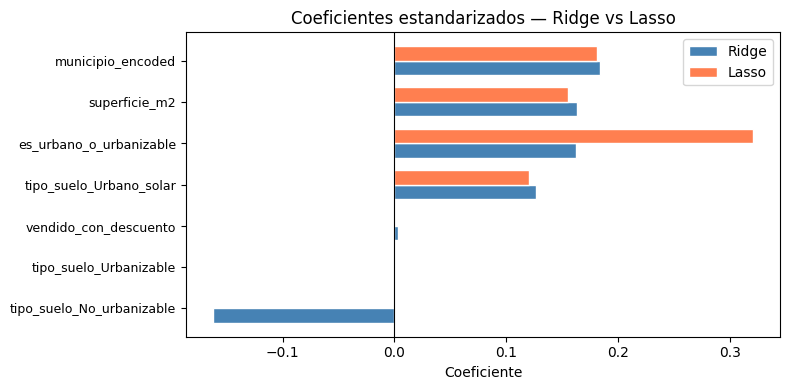

In [10]:
ridge_coefs = pd.Series(
    best_ridge.named_steps['ridge'].coef_,
    index=FEATURES,
    name='Ridge'
)
lasso_coefs.name = 'Lasso'

coef_df = pd.concat([ridge_coefs, lasso_coefs], axis=1).sort_values('Ridge')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(coef_df))
w = 0.35
ax.barh(x - w/2, coef_df['Ridge'], w, label='Ridge', color='steelblue', edgecolor='white')
ax.barh(x + w/2, coef_df['Lasso'], w, label='Lasso', color='coral',     edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(coef_df.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes estandarizados — Ridge vs Lasso')
ax.set_xlabel('Coeficiente')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Diagnóstico de residuos (mejor modelo)

Mejor modelo en test: Lasso


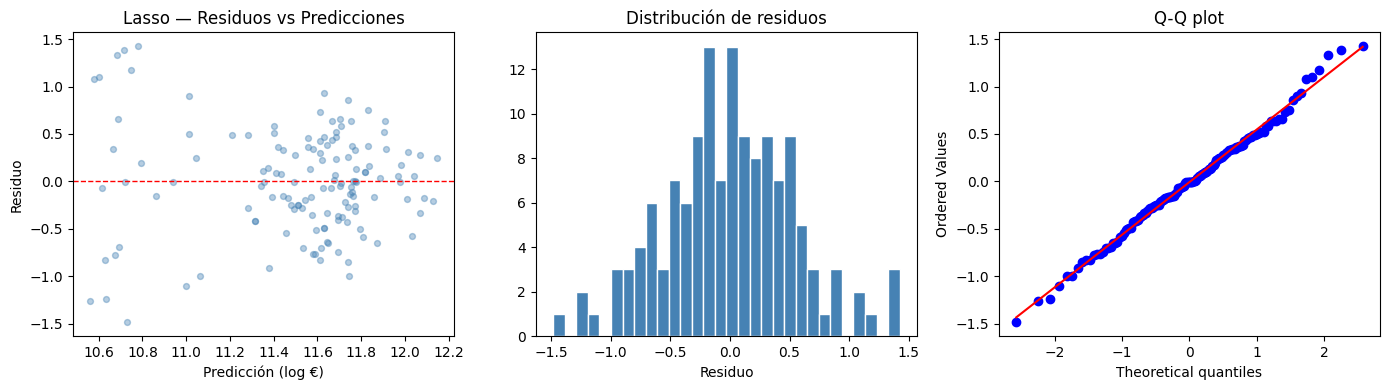

Skewness residuos: 0.0523
Kurtosis residuos: 0.2022


In [11]:
best_name  = 'Ridge' if metrics_ridge['R2_test'] >= metrics_lasso['R2_test'] else 'Lasso'
best_model = best_ridge if best_name == 'Ridge' else best_lasso
print(f'Mejor modelo en test: {best_name}')

y_pred_test = best_model.predict(X_test)
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_pred_test, residuals, alpha=0.4, color='steelblue', s=18)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicción (log €)')
axes[0].set_ylabel('Residuo')
axes[0].set_title(f'{best_name} — Residuos vs Predicciones')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo')

stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.tight_layout()
plt.show()

print(f'Skewness residuos: {pd.Series(residuals).skew():.4f}')
print(f'Kurtosis residuos: {pd.Series(residuals).kurtosis():.4f}')

## 8. Error en euros (interpretabilidad)

Error absoluto medio  :     43,124 €
Error mediano         :     35,972 €
Error percentil 90    :     91,407 €


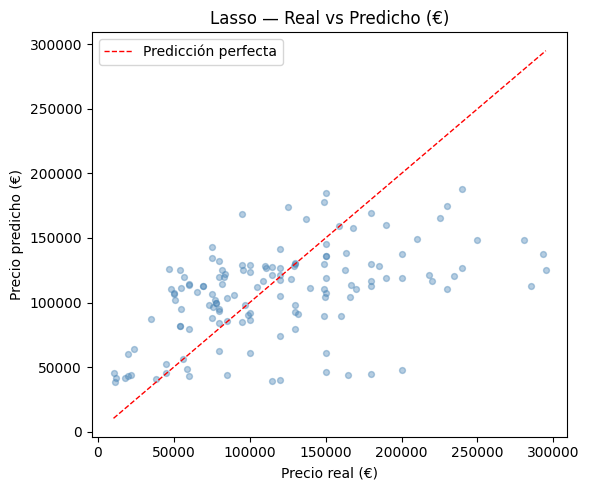

In [12]:
y_real_eur = np.exp(y_test.values)
y_pred_eur = np.exp(y_pred_test)
error_eur  = np.abs(y_real_eur - y_pred_eur)

print(f'Error absoluto medio  : {error_eur.mean():>10,.0f} €')
print(f'Error mediano         : {np.median(error_eur):>10,.0f} €')
print(f'Error percentil 90    : {np.percentile(error_eur, 90):>10,.0f} €')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_real_eur, y_pred_eur, alpha=0.4, color='steelblue', s=18)
lim = [min(y_real_eur.min(), y_pred_eur.min()), max(y_real_eur.max(), y_pred_eur.max())]
ax.plot(lim, lim, 'r--', linewidth=1, label='Predicción perfecta')
ax.set_xlabel('Precio real (€)')
ax.set_ylabel('Precio predicho (€)')
ax.set_title(f'{best_name} — Real vs Predicho (€)')
ax.legend()
plt.tight_layout()
plt.show()